In [5]:
!pip install pandas numpy seaborn matplotlib plotly nbformat ydata-profiling "setuptools<81"

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached nbformat-5.11.1-py3-none-any.whl.metadata (3.7 kB)
  Using cached ydata_profiling-4.18.4-py2.py3-none-any.whl.metadata (23 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached visions-0.8.1-py3-none-any.whl.metadata (11 kB)
  Using cached phik-0.12.5-cp312-cp312-win_amd64.whl.metadata (5.6 kB)
  Using cached statsmodels-0.15.0-cp312-cp312-win_amd64.whl.metadata (9.6 kB)
  Using cached ImageHash-4.3.2-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached wordcloud-1.9.6-cp312-cp312-win_amd64.whl.metadata (3.5 kB)
  Using cached formulaic-1.2.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached nbformat-5.11.1-py3-none-any.whl (79 kB)
Using cached ydata_profiling-4.


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import plotly.express as px
import plotly.io as pio
import sys
from ydata_profiling import ProfileReport

!{sys.executable} -m pip install nbformat --user

C:\Users\aliak\AppData\Local\Temp\ipykernel_36616\254691253.py:10: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport
'c:\Program' is not recognized as an internal or external command,
operable program or batch file.


STEP 1: Data Cleaning, Profiling & Feature Engineering

In [3]:
df = pd.read_csv('dirty_financial_transactions.csv') #Load your chosen dataset into a pandas DataFrame
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_') #Bring the DataFrame structure into compliance with Python standards (PEP8)

print(df.head()) #Check and correct data types
df.info()


  transaction_id transaction_date customer_id    product_name  quantity  \
0          T0001       2024-08-02       C2205      Headphones      -5.0   
1          T0002       2020-02-10       C3156         Coffee      469.0   
2          T0003       2025-02-30       C2919          Tablet      -4.0   
3          T0004       2020-08-17       C3009             Tab      -7.0   
4          T0005       2025-02-30       C3488  Coffee Machine     -10.0   

                 price payment_method transaction_status  
0              $420.21        pay pal                NaN  
1  -445.34202525395585     creditcard            Pending  
2    810.9930123946459    credit card          completed  
3    868.6083413217348         PayPal            Pending  
4   -763.1224490039416         PayPal          completed  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              -----------

In [ ]:
eda = ProfileReport(df, title="EDA Report", explorative=True) #Perform automated exploratory data analysis using any profiling library
eda.to_file("eda_report.html")

In [4]:
df['price'] = df['price'].astype(str).str.replace('$', '', regex=False)

df['price'] = pd.to_numeric(df['price'], errors='coerce') #Check and correct data types
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

len_with_duplicates =len(df) #Handle missing values and duplicates
df = df.drop_duplicates()
print(f"Dropped {len_with_duplicates - len(df)} duplicate rows.")

if 'transaction_id' in df.columns:
    df = df.drop_duplicates('transaction_id', keep='first')

df = df.dropna(subset=['customer_id', 'transaction_date'])

df.loc[df['price'] <= 0, 'price'] = np.nan #Filter the dataset to exclude any potential test, buggy, or irrelevant records
df.loc[df['quantity'] <= 0, 'quantity'] = np.nan

df['quantity'] = df['quantity'].fillna(1) 

df['price'] = df['price'].fillna(df.groupby('product_name')['price'].transform('median')) 
df['price'] = df['price'].fillna(df['price'].median())

df['transaction_status'] = df['transaction_status'].astype(str).str.strip().str.lower()
df['payment_method'] = df['payment_method'].astype(str).str.lower().str.replace(r'\s+', '', regex=True)

print(df['product_name'].value_counts(dropna=False))

def standardize_product_name(name):
    if not isinstance(name, str):
        return 'Other'
    
    val = name.strip().lower()
    
    if val.startswith(('head', 'headp', 'headph', 'headpho', 'headphon', 'headphone', 'hea', 'he', 'h', 'ear')):
        return 'Headphones'
    
    elif val.startswith(('smart', 'smartp', 'smartph', 'smartpho', 'smartphon', 'smartphone', 'sma', 'sm', 's', 'phone')):
        return 'Smartphone'
    
    elif val.startswith(('coffee', 'coffee m', 'coffee ma', 'coffee mac', 'coffee mach', 'coffee machi', 'coffee machin', 'cof', 'coffe', 'co', 'c')):
        return 'Coffee Machine'
    
    elif val.startswith(('tablet', 'tabl', 'tab', 'ta', 'table', 't')):
        return 'Tablet'
    
    elif val.startswith(('laptop', 'lapto', 'lapt', 'lap', 'la', 'l')):
        return 'Laptop'
    
    else:
        return 'Other'

df['product_name'] = df['product_name'].apply(standardize_product_name)

df['total_amount'] = df['price'] * df['quantity'] #Create a new categorical column called value_tier based on a numerical column
df['value_tier'] = pd.qcut(df['total_amount'], q=3, labels=['Low', 'Medium', 'High'])

df['transaction_day_of_week'] = df['transaction_date'].dt.day_name() #Extract the day of the week into a new column


print(df['transaction_status'].value_counts(dropna=False))

def standardize_status(status):
    if pd.isna(status):
        return 'Not specified'

    status_lower = str(status).strip().lower()

    mapping = {
        'completed': 'Completed',
        'complete': 'Completed',
        'pending': 'Pending',
        'failed': 'Failed',
        'not specified': 'Not specified',
        'unknown': 'Not specified'
    }
    
    return mapping.get(status_lower, 'Not specified')
df['transaction_status'] = df['transaction_status'].apply(standardize_status)

def capitalize_dataframe(df):
    df = df.copy()
    
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].apply(lambda x: str(x).capitalize() if pd.notna(x) and isinstance(x, str) else x)
    return df
df = capitalize_dataframe(df)

Dropped 994 duplicate rows.
product_name
Tablet            5247
Laptop            5246
Coffee Machine    5199
Smartphone        5114
Headphones        5039
T                  123
Lapt               109
Ta                 108
Tab                103
Tabl                99
Table               98
La                  95
Lap                 90
L                   89
Lapto               88
Smartph             73
H                   67
Headphone           65
S                   64
Headp               63
Smartp              61
Smar                61
He                  61
Head                60
Smart               60
Sma                 60
Sm                  57
Headph              57
Headpho             54
Hea                 54
Headphon            53
Smartphon           52
Smartpho            50
Coffee Machi        45
Coffee Ma           44
Coffee              42
Coffee Mach         41
Coffe               41
C                   40
Cof                 40
Coffee Mac          39
Coffee Machin   

1. Main Anomalies and Insights in the Raw Data:

Invalid dates: The dataset had impossible dates like February 30th, or 13-th month, which had to be filtered out.

Negative numbers: Some prices and quantities were zero or negative, so I replaced them with NaN to fix them later.

Duplicates: There were repeated transaction IDs and full duplicate rows that needed to be dropped.

Messy text: Fields like payment methods and product names had inconsistent capitalization, typos, and extra spaces.

Missing values: Some rows lacked essential info like customer IDs and dates, while missing prices were filled using group medians.


2. Why Extracting Features Like "Day of the Week" or Keywords is Valuable for the Director:

Tracking sales patterns ("Day of the Week"): Helps see which days are the busiest, making it easier to plan staffing and promotions.

Clean product groups: Turning messy names into clear categories (like Smartphone or Laptop) lets leadership quickly understand what sells best.


STEP 2: Visual EDA

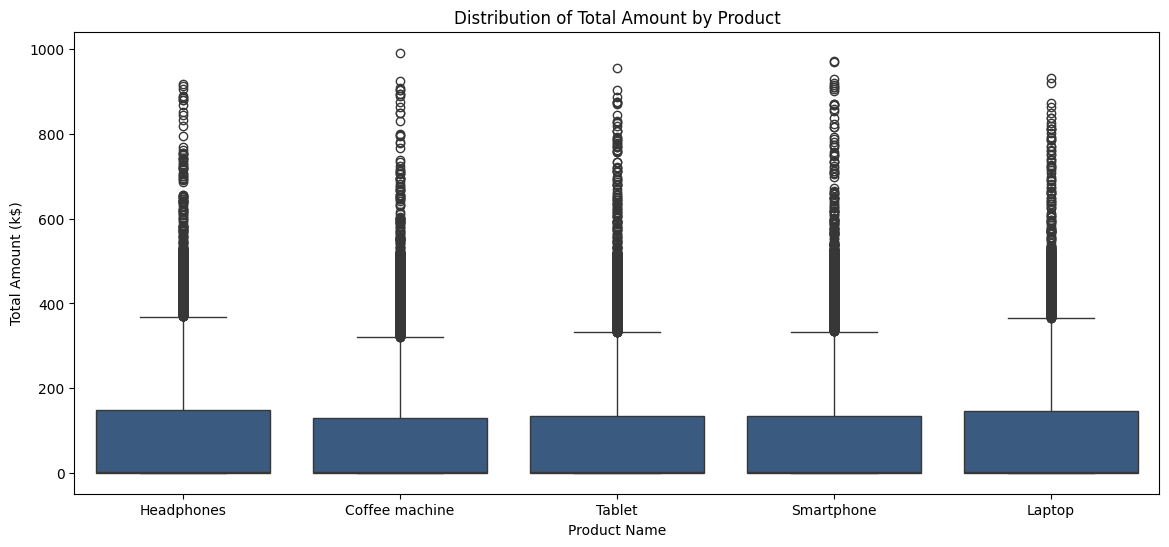

In [5]:
#Distribution Analysis: Analyze a key performance metric across different categories

%matplotlib inline

plt.figure(figsize=(14, 6))
sns.boxplot(x='product_name', y=df['total_amount'] / 1000, data=df, color="#2e598b")

plt.title('Distribution of Total Amount by Product')
plt.xlabel('Product Name')
plt.ylabel('Total Amount (k$)')
plt.show()

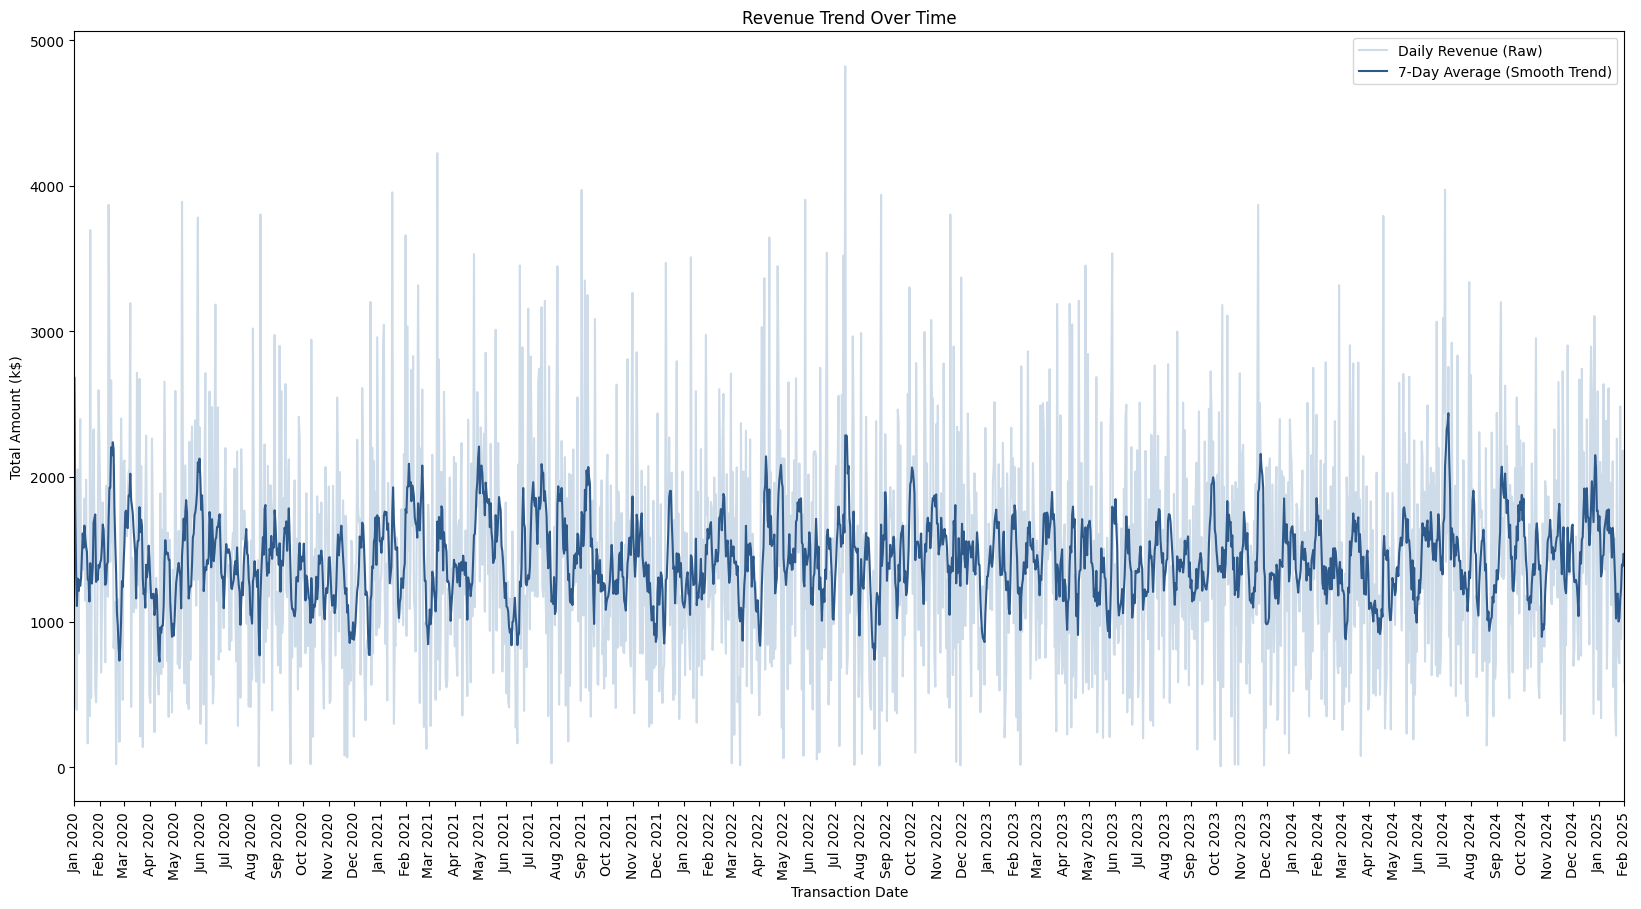

In [6]:
#Trend and Noise Reduction: Visualize the dynamics of the company's main metric over time

df_trend = df.groupby('transaction_date')['total_amount'].sum().reset_index()
df_trend = df_trend.sort_values('transaction_date')

df_trend['smoothed_amount'] = df_trend['total_amount'].rolling(window=7, min_periods=1).mean()
df_trend['total_amount_k'] = df_trend['total_amount'] / 1000
df_trend['smoothed_amount_k'] = df_trend['smoothed_amount'] / 1000

plt.figure(figsize=(20, 10))
plt.plot(df_trend['transaction_date'], df_trend['total_amount_k'], label='Daily Revenue (Raw)', color="#cedbe8")
plt.plot(df_trend['transaction_date'], df_trend['smoothed_amount_k'], label='7-Day Average (Smooth Trend)', color="#2e598b")

plt.title('Revenue Trend Over Time')
plt.xlabel('Transaction Date')
plt.ylabel('Total Amount (k$)')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) 
plt.xlim(df_trend['transaction_date'].min(), df_trend['transaction_date'].max())
plt.xticks(rotation=90)
plt.legend()
plt.show()

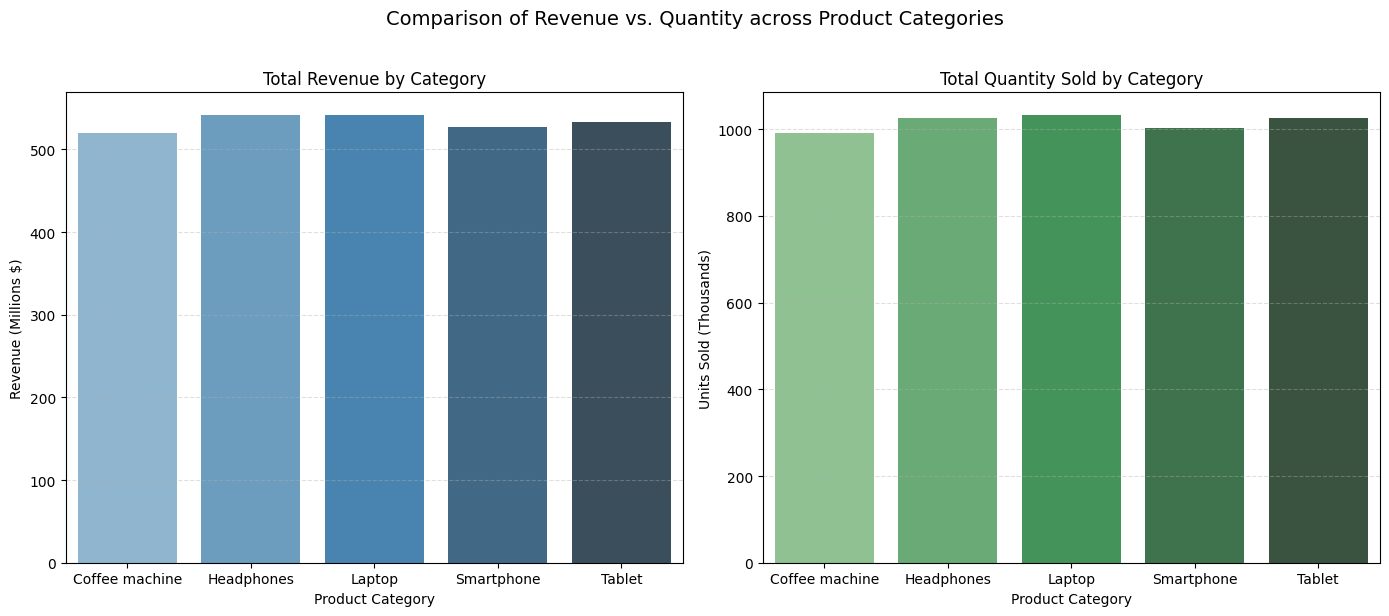

In [7]:
# Compare two main metrics simultaneously across different regions/categories/years

df_comp = df.groupby('product_name')[['total_amount', 'quantity']].sum().reset_index()

df_comp['total_amount_mln'] = df_comp['total_amount'] / 1000000
df_comp['quantity_k'] = df_comp['quantity'] / 1000

df_melted = df_comp.melt(
    id_vars='product_name', 
    value_vars=['total_amount_mln', 'quantity_k'], 
    var_name='Metric', 
    value_name='Value'
)

df_melted['Metric'] = df_melted['Metric'].map({
    'total_amount_mln': 'Total Revenue (Millions $)', 
    'quantity_k': 'Total Quantity (Thousands Units)'
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    ax=axes[0],
    x='product_name', 
    y='Value', 
    data=df_melted[df_melted['Metric'] == 'Total Revenue (Millions $)'],
    palette='Blues_d',
    hue='product_name',
    legend=False
)
axes[0].set_title('Total Revenue by Category')
axes[0].set_ylabel('Revenue (Millions $)')
axes[0].set_xlabel('Product Category')
axes[0].grid(True, linestyle='--', alpha=0.4, axis='y')

sns.barplot(
    ax=axes[1],
    x='product_name', 
    y='Value', 
    data=df_melted[df_melted['Metric'] == 'Total Quantity (Thousands Units)'],
    palette='Greens_d',
    hue='product_name',
    legend=False
)
axes[1].set_title('Total Quantity Sold by Category')
axes[1].set_ylabel('Units Sold (Thousands)')
axes[1].set_xlabel('Product Category')
axes[1].grid(True, linestyle='--', alpha=0.4, axis='y')

plt.suptitle('Comparison of Revenue vs. Quantity across Product Categories', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

1. Seasonal Patterns: 

Looking at the trend chart, sales actually stay quite strong or even peak during the summer months, rather than dropping all the time. This could be because summer is a popular time for vacations, outdoor activities, and people upgrading their tech or gadgets before traveling. The slower periods usually happen later, or right after major spending seasons when consumer activity cools down.

2. Long format: 

A long format means that each row is a single observation, and the data is stacked vertically so that different metrics share the same column instead of spreading out horizontally. This makes life much easier for libraries like Seaborn because you can just point to the metric column and filter what you want to plot without writing messy code. To get this ready for the comparison chart, I used the .melt() function in Pandas, which turned wide columns into a clean, long format.

STEP 3: Interactive Visualization & Data Enrichment (Plotly)

In [8]:
# Create a small supplementary dictionary or DataFrame containing Managers
managers_df = pd.DataFrame({
    'product_name': ['Smartphone', 'Coffee Machine', 'Tablet', 'Laptop', 'Headphones', 'Other'],
    'Manager': ['Anna', 'John', 'Michael', 'Anna', 'John', 'Michael'],
    'Branch': ['Branch A', 'Branch B', 'Branch C', 'Branch A', 'Branch B', 'Branch C'],
    'City': ['Warsaw', 'Berlin', 'Paris', 'Prague', 'Vienna', 'Madrid'],
    'Country': ['Poland', 'Germany', 'France', 'Czechia', 'Austria', 'Spain'],
    'lat': [52.2297, 52.5200, 48.8566, 50.0755, 48.2082, 40.4168],
    'lon': [21.0122, 13.4050, 2.3522, 14.4378, 16.3738, -3.7038]
})

cols_to_drop = [col for col in df.columns if col in ['Manager', 'Branch', 'City', 'Country', 'lat', 'lon'] or '_new' in col or '_y' in col or '_x' in col]
df = df.drop(columns=cols_to_drop, errors='ignore')

df['product_name'] = df['product_name'].astype(str).str.strip().str.title()

df = pd.merge(df, managers_df, on='product_name', how='left')

# Build an interactive geographical chart that allows the user to hover over different locations and see their total volume
df_geo = df.groupby(['Country', 'City', 'lat', 'lon'], as_index=False)['total_amount'].sum()

fig_map = px.scatter_geo(
    df_geo,
    lat='lat',
    lon='lon',
    size='total_amount',
    color='Country',
    hover_name='City',
    hover_data={'Country': True, 'total_amount': ':.2f', 'lat': False, 'lon': False},
    projection='natural earth',
    title='Geographical Distribution of Revenue'
)
fig_map.update_layout(template='plotly_white')
fig_map.show()

hierarchy_cols = ['Manager', 'Branch', 'product_name', 'transaction_status']
for col in hierarchy_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')
        df[col] = df[col].astype(str).str.strip()

# Create an interactive chart that effectively displays the part-to-whole relationship
fig_sunburst = px.sunburst(
    df,
    path=['Manager', 'Branch', 'product_name', 'transaction_status'],
    values='total_amount',
    color='transaction_status',
    title="Hierarchical Drill-Down: Manager -> Branch -> Category -> Status"
)
fig_sunburst.update_layout(margin=dict(t=50, l=0, r=0, b=0))
fig_sunburst.show()

1. Manager with the most problematic sub-category:

Anna has the most noticeable failed and pending transactions in category Smartphone.
If I were this manager, my immediate steps would be to check with the logistics or payment team to find out why transactions are failing, fix any technical bottlenecks in the checkout process, and closely monitor this specific product category to reduce lost revenue.


2. Difference between pd.merge(), DataFrame.join(), and Series.map(). 

pd.merge(): Combines two dataframes based on common columns or indexes (like a SQL JOIN). It's used when you need to match multiple columns across datasets.

DataFrame.join(): Primarily joins dataframes based on their indexes rather than columns, which makes it fast for index-based lookups.

Series.map(): Used to map values of a single column based on a dictionary or another series (like a lookup table for one specific column).


3. Which approach did I choose to add the Managers to your dataset, and why?

I used pd.merge() because I needed to attach multiple columns (Manager, Branch, City, coordinates, etc.) from dictionary to the main dataframe based on a matching category key, which is exactly what a merge operation is designed for.

STEP 4: Product/Entity & User Analytics

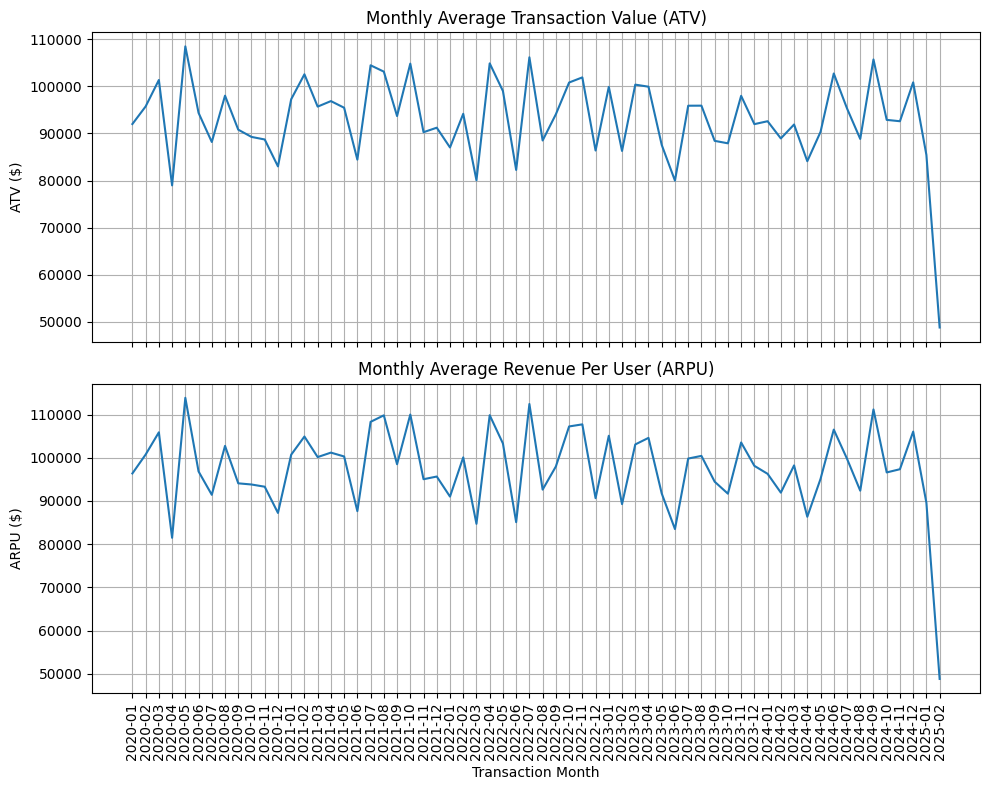

In [9]:
# Group the data and visualize the monthly dynamics of your domain's key metrics

df['transaction_month'] = df['transaction_date'].dt.to_period('M').astype(str)

monthly_metrics = df.groupby('transaction_month').agg(
    total_revenue=('total_amount', 'sum'),
    total_transactions=('transaction_id', 'count') if 'transaction_id' in df.columns else ('price', 'count'),
    unique_users=('customer_id', 'nunique')
).reset_index()

monthly_metrics['ATV'] = monthly_metrics['total_revenue'] / monthly_metrics['total_transactions']
monthly_metrics['ARPU'] = monthly_metrics['total_revenue'] / monthly_metrics['unique_users']

monthly_metrics['transaction_month_str'] = monthly_metrics['transaction_month'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

sns.lineplot(data=monthly_metrics, x='transaction_month_str', y='ATV', ax=axes[0])
axes[0].set_title('Monthly Average Transaction Value (ATV)')
axes[0].set_ylabel('ATV ($)')
axes[0].grid(True)

sns.lineplot(data=monthly_metrics, x='transaction_month_str', y='ARPU', ax=axes[1])
axes[1].set_title('Monthly Average Revenue Per User (ARPU)')
axes[1].set_xlabel('Transaction Month')
axes[1].set_ylabel('ARPU ($)')
axes[1].grid(True)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

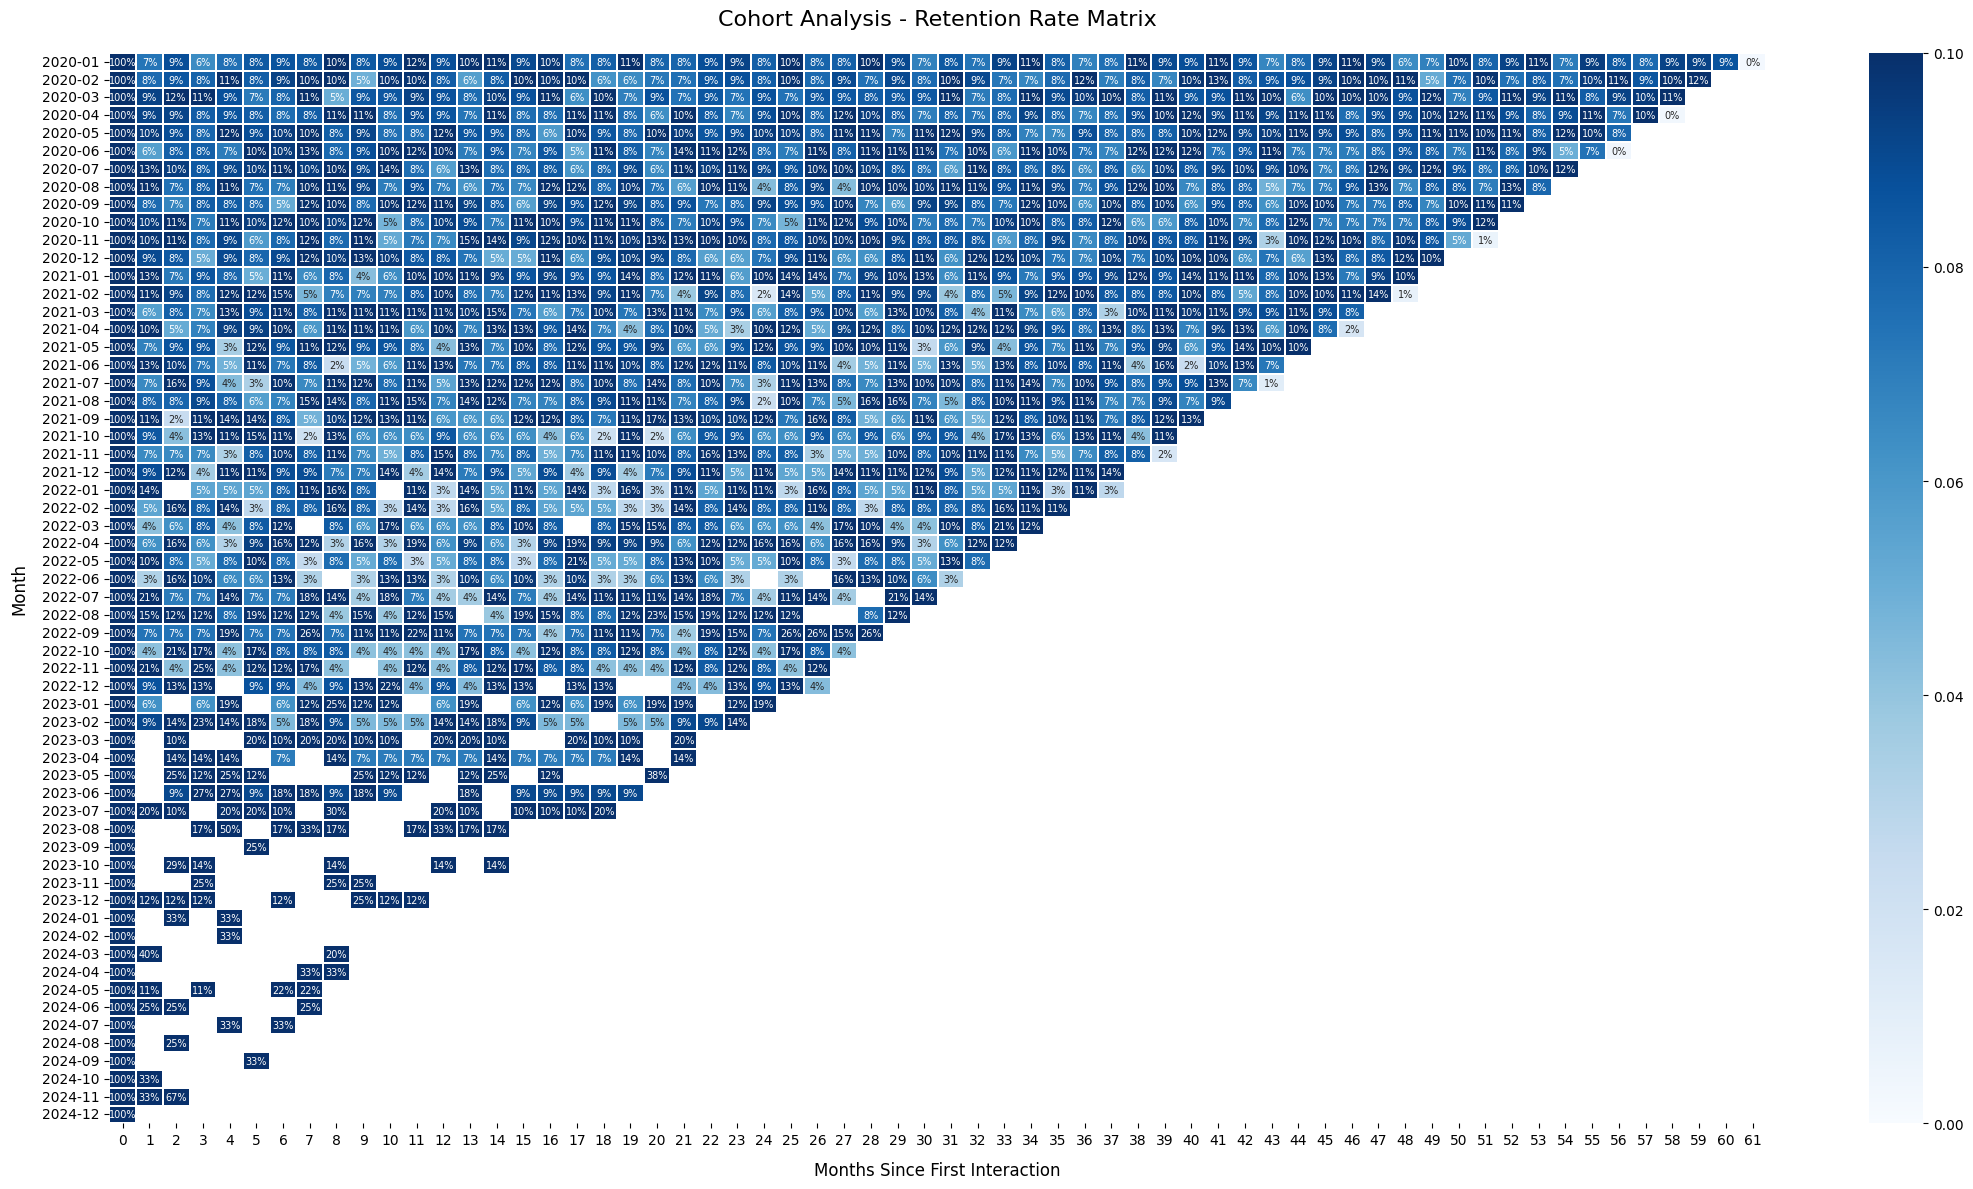

In [10]:
#Build a retention matrix by the month of the user's/entity's first interaction

df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

order_year = df['transaction_date'].dt.year
order_month = df['transaction_date'].dt.month
df['order_period_num'] = order_year * 12 + order_month

first_order_num = df.groupby('customer_id')['order_period_num'].transform('min')
df['cohort_month'] = df.groupby('customer_id')['transaction_date'].transform('min').dt.to_period('M')
df['cohort_index'] = df['order_period_num'] - first_order_num

cohort_data = df.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index()
cohort_matrix = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_id')

cohort_sizes = cohort_matrix.iloc[:, 0]
retention_matrix = cohort_matrix.divide(cohort_sizes, axis=0)
retention_matrix.columns = retention_matrix.columns.astype(int)

plt.figure(figsize=(22, 12))
ax = sns.heatmap(
    retention_matrix, 
    annot=True,              
    fmt='.0%',               
    cmap='Blues',          
    vmin=0.0,              
    vmax=0.1,              
    cbar=True,             
    linewidths=0.2,        
    linecolor='white',
    annot_kws={"size": 7}  
)

plt.title('Cohort Analysis - Retention Rate Matrix', fontsize=16, pad=20)
plt.xlabel('Months Since First Interaction', fontsize=12, labelpad=10)
plt.ylabel('Month', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

In [ ]:
# RFM Analysis: Calculate Recency, Frequency, and Monetary metrics

valid_data = df.dropna(subset=['customer_id', 'transaction_date', 'total_amount'])
ref_date = valid_data['transaction_date'].max() + pd.Timedelta(days=1)

rfm_df = valid_data.groupby('customer_id').agg(
    recency=('transaction_date', lambda d: (ref_date - d.max()).days),
    frequency=('transaction_date', 'count'),
    monetary=('total_amount', 'sum')
).reset_index()


rfm_df['R_score'] = pd.qcut(rfm_df['recency'].rank(method='first'), q=3, labels=[3, 2, 1]).astype(int)
rfm_df['F_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), q=3, labels=[1, 2, 3]).astype(int)
rfm_df['M_score'] = pd.qcut(rfm_df['monetary'].rank(method='first'), q=3, labels=[1, 2, 3]).astype(int)

rfm_df['RFM_Score'] = rfm_df['R_score'].astype(str) + rfm_df['F_score'].astype(str) + rfm_df['M_score'].astype(str)

def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r == 3 and f >= 2 and m >= 2:
        return 'Champions'
    elif r == 1 and f >= 2:
        return 'At Risk'
    elif r == 3 and f == 1:
        return 'Newbies'
    elif r == 2 and f >= 2:
        return 'At Risk' 
    else:
        return 'Sleeping'

rfm_df['Segment'] = rfm_df.apply(assign_segment, axis=1)

for seg in rfm_df['Segment'].unique():
    print(f"\n- Segment: {seg}")
    top_clients = rfm_df[rfm_df['Segment'] == seg].sort_values('monetary', ascending=False).head(3)
    print(top_clients[['customer_id', 'recency', 'frequency', 'monetary', 'Segment']])


- Segment: At Risk
     customer_id  recency  frequency      monetary  Segment
4161       C4706      147         12  2.646330e+06  At Risk
4330        C486      517          9  2.402080e+06  At Risk
4640        C658      203         11  2.380551e+06  At Risk

- Segment: Champions
     customer_id  recency  frequency      monetary    Segment
3982       C4543       79         13  2.688774e+06  Champions
879        C1711       10         12  2.592908e+06  Champions
4708        C726       43          9  2.513677e+06  Champions

- Segment: Sleeping
     customer_id  recency  frequency      monetary   Segment
3037       C3680      805          3  1.701804e+06  Sleeping
2964       C3614      261          4  1.570918e+06  Sleeping
3107       C3744      376          3  1.543160e+06  Sleeping

- Segment: Newbies
     customer_id  recency  frequency      monetary  Segment
2229       C2943       93          4  1.750513e+06  Newbies
641        C1494       64          4  1.563628e+06  Newbies
1920 

1.  At what month after the first interaction do we lose the majority of our base according to your cohort matrix? Write a brief action plan: What specific campaign or action would you suggest for the "Champions" segment vs. the "At Risk" segment to maximize business value?

Looking at the retention matrix, the dramatic drop happens right after month 0. Retention immediately falls from 100% to around 7–13% by Month 1, meaning we lose the majority of our active base almost instantly after the first interaction.
Plan:
For "Champions": Launch an exclusive loyalty and VIP rewards program offering early access to new products, personalized discounts, and priority support to maintain their high engagement and prevent churn.

For "At Risk": Deploy a targeted automated "We Miss You" win-back email campaign with special limited-time discounts or tailored product recommendations based on their past high-value purchases to re-engage them before they slip into the Sleeping category.


2. Compare the performance and readability of different ways to create categorical columns in pandas. Which approach did you use for the value_tier and RFM segmentation, and why? 

Approaches in pandas include mapping (.map()), conditional assignments (np.select()), and pd.qcut().
For RFM and value tiers, pd.qcut() combined with .rank(method='first') was chosen because it cleanly automates quantile-based ranking without manual threshold tuning and handles ties smoothly.

3. When calculating the first interaction date for cohort analysis, explain the difference in output shape between using .transform('min') and .groupby().min(). Which one is more suitable for adding a new column directly to the original dataframe?

.groupby().min() returns a reduced-size dataframe indexed by the grouped columns, whereas .transform('min') broadcasts the aggregated minimum value back to match the original dataframe's exact shape and index.

.transform('min') is the correct and suitable choice for adding the first interaction date directly as a new column to the original dataframe because it preserves row alignment and length.

STEP 5: Export to CSV

In [ ]:
valid_data.to_csv('cleaned_financial_transactions.csv', index=False)

rfm_df.to_csv('dim_customer_rfm.csv', index=False)